# Analyse en composantes principales

Objectif du notebook : Etudier la répartition naturel des données dans des groupes distincts ou non et observer si la réduction de variables par ACP est une bonne option de réduction du nombre de variables.

## Imports

In [56]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["OMP_NUM_THREADS"] = "1"

# Préparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ACP / PCA
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Modèle supervisé
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Paramètres globaux
RANDOM_STATE = 42

sns.set_style("whitegrid")

In [57]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## Chargement des données

On charge le CSV contenant les coordonnées MediaPipe nettoyées.

In [58]:
# Chargement du fichier CSV
CSV_PATH = "exports/coordonnees_clean.csv"

df = pd.read_csv(CSV_PATH)
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (284, 85)


,nez_x,nez_y,nez_z,nez_vis,oeil_gauche_x,oeil_gauche_y,oeil_gauche_z,oeil_gauche_vis,oeil_droit_x,oeil_droit_y,oeil_droit_z,oeil_droit_vis,oreille_gauche_x,oreille_gauche_y,oreille_gauche_z,oreille_gauche_vis,oreille_droite_x,oreille_droite_y,oreille_droite_z,oreille_droite_vis,epaule_gauche_x,epaule_gauche_y,epaule_gauche_z,epaule_gauche_vis,epaule_droite_x,epaule_droite_y,epaule_droite_z,epaule_droite_vis,coude_gauche_x,coude_gauche_y,coude_gauche_z,coude_gauche_vis,coude_droit_x,coude_droit_y,coude_droit_z,coude_droit_vis,poignet_gauche_x,poignet_gauche_y,poignet_gauche_z,poignet_gauche_vis,poignet_droit_x,poignet_droit_y,poignet_droit_z,poignet_droit_vis,hanche_gauche_x,hanche_gauche_y,hanche_gauche_z,hanche_gauche_vis,hanche_droite_x,hanche_droite_y,hanche_droite_z,hanche_droite_vis,genou_gauche_x,genou_gauche_y,genou_gauche_z,genou_gauche_vis,genou_droit_x,genou_droit_y,genou_droit_z,genou_droit_vis,cheville_gauche_x,cheville_gauche_y,cheville_gauche_z,cheville_gauche_vis,cheville_droite_x,cheville_droite_y,cheville_droite_z,cheville_droite_vis,talon_gauche_x,talon_gauche_y,talon_gauche_z,talon_gauche_vis,talon_droit_x,talon_droit_y,talon_droit_z,talon_droit_vis,pied_gauche_x,pied_gauche_y,pied_gauche_z,pied_gauche_vis,pied_droit_x,pied_droit_y,pied_droit_z,pied_droit_vis,label
0,0.637621,0.138610,0.233582,0.999896,0.644267,0.119031,0.179639,0.999958,0.651184,0.117968,0.221253,0.999905,0.658861,0.121825,-0.008663,0.999933,0.676635,0.120116,0.178771,0.999929,0.630811,0.216003,-0.113659,0.999924,0.742125,0.226438,0.250747,0.999974,0.579695,0.323499,-0.046928,0.230770,0.729544,0.322628,0.457268,0.047281,0.579535,0.336415,0.222887,0.092411,0.670643,0.297396,0.622107,0.037801,0.567905,0.440322,-0.132421,0.999775,0.620948,0.485307,0.132092,0.999948,0.421189,0.342786,-0.007688,0.966624,0.607213,0.683587,0.210872,0.982059,0.252499,0.292247,0.079139,0.974156,0.616636,0.884979,0.259843,0.995039,0.229521,0.317571,0.089154,0.969566,0.618542,0.914481,0.268425,0.991724,0.201480,0.243661,0.067086,0.914758,0.615645,0.909720,0.222452,0.971388,ap_tchagui
1,0.269730,0.257379,-0.114015,0.999281,0.261025,0.242842,-0.074119,0.999220,0.243149,0.248696,-0.117047,0.999098,0.249863,0.256067,0.133121,0.996826,0.208939,0.269285,-0.059929,0.999367,0.343602,0.325835,0.304861,0.999866,0.198470,0.378694,-0.137537,0.999944,0.481204,0.357233,0.249011,0.406855,0.336028,0.434665,-0.279777,0.955339,0.485047,0.283434,-0.019082,0.549412,0.418837,0.333218,-0.308527,0.912115,0.485030,0.496223,0.111620,0.999873,0.421646,0.549871,-0.112107,0.999919,0.556498,0.465573,0.035193,0.884316,0.531499,0.711204,0.002241,0.905460,0.651428,0.408756,-0.027015,0.971182,0.576181,0.848730,0.151646,0.795450,0.681122,0.405885,-0.043195,0.959354,0.562040,0.871316,0.162703,0.752584,0.644928,0.377261,-0.212476,0.969100,0.617407,0.870777,0.008565,0.859083,ap_tchagui
2,0.561428,0.165053,0.214194,0.999961,0.572796,0.145410,0.166621,0.999978,0.577162,0.146304,0.206116,0.999946,0.589125,0.149343,-0.008461,0.999953,0.600202,0.149610,0.168913,0.999948,0.568778,0.248855,-0.120343,0.999977,0.668403,0.258166,0.219682,0.999993,0.526372,0.366793,-0.213030,0.845878,0.607905,0.382140,0.258069,0.201924,0.524079,0.471982,-0.170532,0.662537,0.553256,0.453123,0.214548,0.279889,0.497681,0.461892,-0.109432,0.999954,0.542620,0.504566,0.109788,0.999990,0.358221,0.362019,-0.001340,0.990126,0.534509,0.705341,0.165522,0.996203,0.211572,0.283460,0.081799,0.994177,0.541183,0.912203,0.242902,0.996865,0.193005,0.282521,0.085926,0.989619,0.537759,0.937577,0.249350,0.994461,0.176738,0.213497,0.011807,0.989347,0.547044,0.946837,0.178241,0.991011,ap_tchagui
3,0.448500,0.242430,0.075736,0.999923,0.435312,0.229039,0.122694,0.999854,0.425200,0.230837,0.050862,0.999940,0.399928,0.243526,0.305615,0.999749,0.379280,0.244713,-0.016470,0.999845,0.421189,0.351085,0.508321,0.999955,0.342212,0.348051,-0.184290,0.999989,0.522743,0.491289,0.532143,0.170002,0.354522,0.479762,-0.339284,0.896081,0.634659,0.515283,0.319666,0.403738,

In [59]:
# Colonne cible
TARGET_COL = "label"

print("Colonne cible :", TARGET_COL)
print(df[TARGET_COL].value_counts())

# On ne garde que les colonnes numériques comme variables explicatives.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

X = df[numeric_cols].copy()
y_raw = df[TARGET_COL].copy()

print("Nombre de variables numériques :", len(numeric_cols))
print("Shape X :", X.shape)

Colonne cible : label
label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64
Nombre de variables numériques : 84
Shape X : (284, 84)


## Encodage des labels

In [60]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

## PCA exploratoire sur tout le dataset

In [61]:
# La PCA est sensible à l'échelle des variables.
# On standardise donc toutes les coordonnées
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

In [62]:
# PCA complète : on ne fixe pas le nombre de composantes.
# Cela permet d'observer toute la variance expliquée.
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_full)

# Tableau de variance expliquée
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_)
})

# Affichage des 15 premières composantes
display(explained_variance.head(15))

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.204366,0.204366
1,PC2,0.145543,0.349908
2,PC3,0.121184,0.471092
3,PC4,0.109607,0.580699
4,PC5,0.098515,0.679214
5,PC6,0.066372,0.745585
6,PC7,0.044350,0.789936
7,PC8,0.031116,0.821051
8,PC9,0.028505,0.849556
9,PC10,0.022197,0.871752


In [63]:
# Nombre de composantes nécessaires pour atteindre certains seuils de variance cumulée
for threshold in [0.90]:
    n_components = np.argmax(explained_variance["cumulative_variance"] >= threshold) + 1
    print(f"Nombre de composantes pour atteindre {int(threshold * 100)} % de variance : {n_components}")

Nombre de composantes pour atteindre 90 % de variance : 12


## Visualisation de la variance

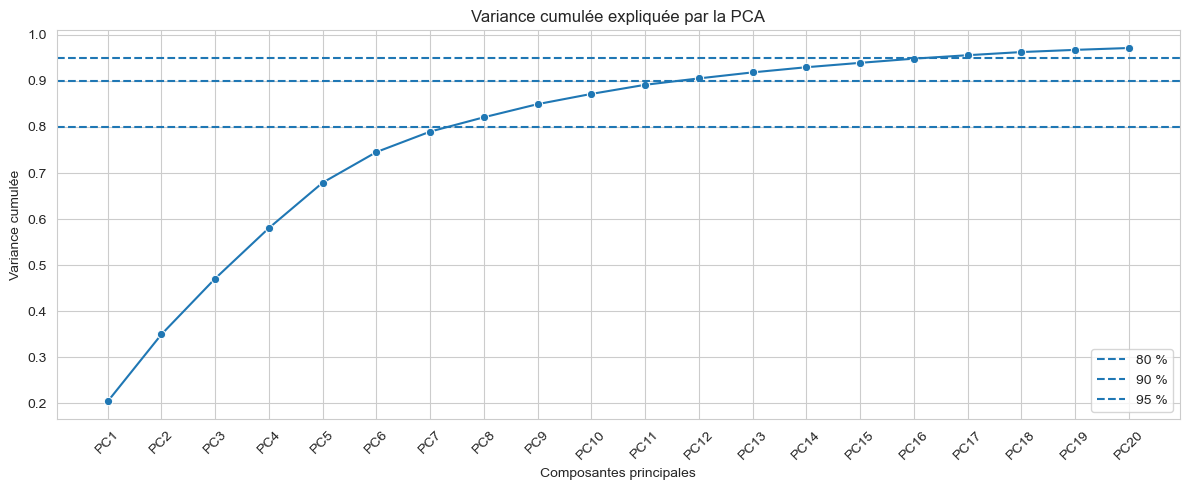

In [64]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=explained_variance.head(20),
    x="component",
    y="cumulative_variance",
    marker="o"
)

plt.axhline(0.80, linestyle="--", label="80 %")
plt.axhline(0.90, linestyle="--", label="90 %")
plt.axhline(0.95, linestyle="--", label="95 %")

plt.xticks(rotation=45)
plt.title("Variance cumulée expliquée par la PCA")
plt.xlabel("Composantes principales")
plt.ylabel("Variance cumulée")
plt.legend()
plt.tight_layout()
plt.show()

## Cercle des corrélations

In [65]:
# PCA finale 
# le nombre de composantes idéales a été déterminé précédemment à partir de la variance expliquée cumulée.
# Ici, il vaut 12.
N_COMPONENTS_PCA = n_components

# Création de la PCA avec le nombre de composantes sélectionnée
# La PCA va constuire les nouvelles variables (composantes principales) qui résument l'information contenue dans les variables d'origine.
pca_final = PCA(
    n_components=N_COMPONENTS_PCA
)

# Projection des données standardisées dans le nouvel espace PCA.
X_pca_final = pca_final.fit_transform(
    X_scaled_full
)

print(
    "taille du dataset après PCA :",
    X_pca_final.shape
)

taille du dataset après PCA : (284, 12)


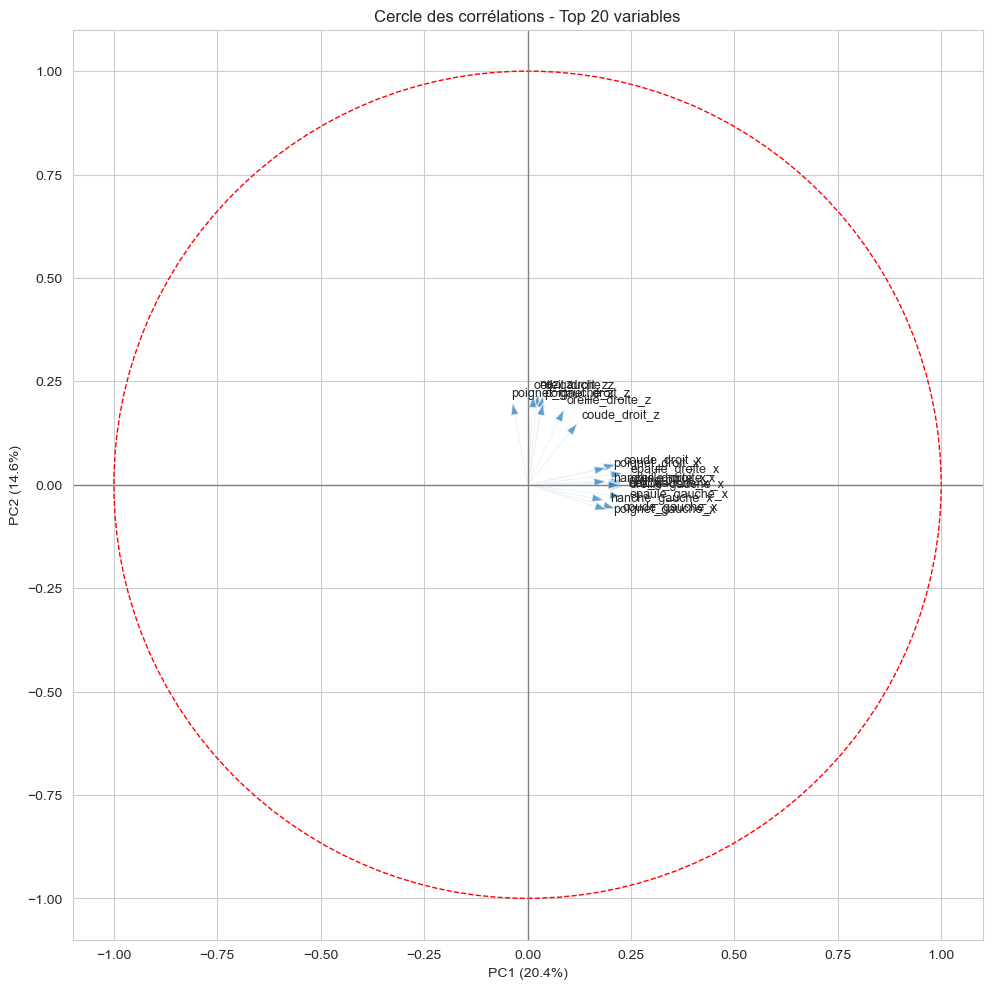

In [66]:
# Cercle des corrélations
# Les composantes de la PCA indiquent la contribution de chaque variable aux axes principaux.

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(
            pca_final.n_components_
        )
    ],
    index=X.columns
)

# Importance globale d'une variable
# sur le plan PC1-PC2.
loadings["importance_PC1_PC2"] = (
    loadings["PC1"]**2
    + loadings["PC2"]**2
)

# On conserve uniquement les variables les plus représentatives du plan factoriel.
top_loadings = (
    loadings
    .sort_values(
        by="importance_PC1_PC2",
        ascending=False
    )
    .head(20)
)

# Graphique du cercle des corrélations
plt.figure(figsize=(10, 10))

# Cercle unité
circle = plt.Circle(
    (0, 0),
    1,
    color="red",
    fill=False,
    linestyle="--"
)

plt.gca().add_artist(circle)

# Flèches des variables
for feature in top_loadings.index:
    x = top_loadings.loc[feature, "PC1"]
    y = top_loadings.loc[feature, "PC2"]

    plt.arrow(
        0,
        0,
        x,
        y,
        alpha=0.7,
        head_width=0.02,
        length_includes_head=True
    )

    plt.text(
        x * 1.08,
        y * 1.08,
        feature,
        fontsize=9
    )

# Axes
plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)

# Labels avec variance expliquée
plt.xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]:.1%})")

plt.title("Cercle des corrélations - Top 20 variables")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
# Poids des variables dans chaque composante principale

loadings_final = pd.DataFrame(
    pca_final.components_.T,
    index=X.columns,
    columns=[
        f"PC{i+1}"
        for i in range(pca_final.n_components_)
    ]
)

display(loadings_final)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
nez_x,0.224783,-0.000886,-0.029658,-0.008439,-0.023748,0.076423,0.043521,-0.127158,0.059945,-0.061494,0.028878,-0.003644
nez_y,-0.001004,-0.035287,-0.087040,-0.113140,0.293738,0.019304,0.074147,0.027455,0.003585,-0.085100,-0.003799,-0.050626
nez_z,0.025526,0.219627,0.156556,-0.075258,0.056888,0.008054,-0.054475,-0.052716,-0.067364,-0.020796,-0.054332,0.080665
nez_vis,0.033694,-0.110740,0.146147,-0.000017,-0.063135,-0.012116,0.327365,-0.000006,-0.131303,0.147388,-0.051067,-0.065610
oeil_gauche_x,0.225989,-0.002775,-0.033785,-0.004594,-0.024936,0.064603,0.043502,-0.126067,0.058008,-0.056436,0.029350,0.001301
oeil_gauche_y,0.006237,-0.037546,-0.087945,-0.120827,0.289089,0.016699,0.076245,0.019838,0.000304,-0.096407,-0.001131,-0.056740
oeil_gauche_z,0.014369,0.216093,0.156863,-0.088719,0.053350,0.019380,-0.058261,-0.062420,-0.074146,-0.011839,-0.042684,0.087444
oeil_gauche_vis,0.033967,-0.101443,0.167707,-0.017873,-0.036883,-0.017380,0.332200,0.008118,-0.154768,0.113721,-0.097782,-0.062903
oeil_droit_x,0.226701,0.003091,-0.027560,-0.007217,-0.021287,0.064769,0.043013,-0.123266,0.061023,-0.062736,0.024530,-0.002247
oeil_droit_y,-0.007161,-0.039052,-0.082012,-0.108230,0.297391,0.019518,0.068082,0.032387,-0.000595,-0.091102,-0.007496,-0.060176


## Projection PCA

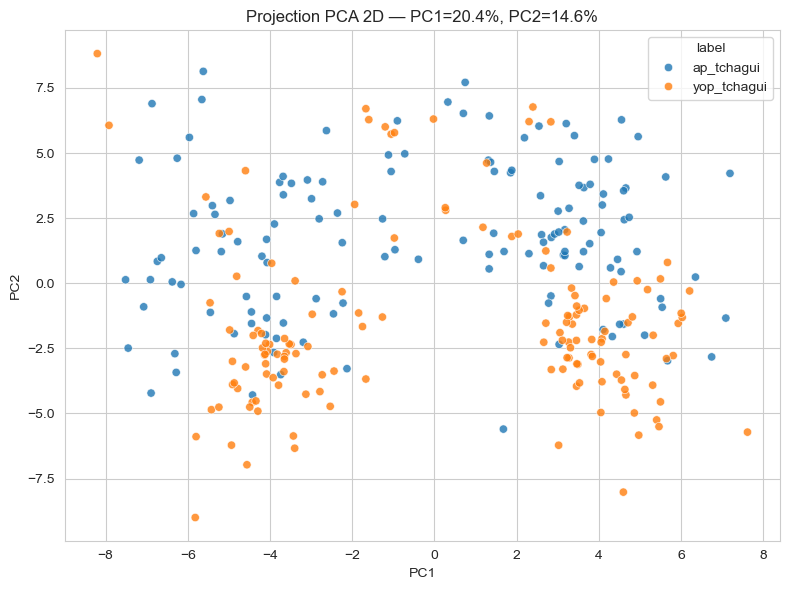

In [68]:
# Projection des données 2 premières composantes principales

# PCA spécifique à la visualisation. On ne conserve que deux composantes afin de représenter les données dans un plan 2D.
pca_2d = PCA(n_components=2)

# Projection des données standardisées sur les deux premières composantes.
X_pca_2d = pca_2d.fit_transform(X_scaled_full)

# Construction d'un DataFrame pour faciliter la création du graphique.
pca_2d_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "label": y_raw.values
})

# Visualisation des observations dans le plan factoriel PC1-PC2.
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_2d_df,
    x="PC1",
    y="PC2",
    hue="label",
    alpha=0.8
)

plt.title(
    f"Projection PCA 2D — "
    f"PC1={pca_2d.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.1%}"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

In [69]:
# Projection en 3D

import plotly.express as px

# PCA dédiée à la visualisation 3D
pca_3d = PCA(n_components=3)

# Projection des données standardisées sur les trois premières composantes.
X_pca_3d = pca_3d.fit_transform(X_scaled_full)

# Construction du DataFrame utilisé pour la visualisation 
pca_3d_df = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "label": y_raw.values
})

# Représentation des observations dans l'espace formé par PC1, PC2 et PC3.
fig = px.scatter_3d(
    pca_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="label",
    opacity=0.8,
    title=(
        f"PCA 3D "
        f"(PC1={pca_3d.explained_variance_ratio_[0]:.1%}, "
        f"PC2={pca_3d.explained_variance_ratio_[1]:.1%}, "
        f"PC3={pca_3d.explained_variance_ratio_[2]:.1%})"
    )
)

fig.show()

L'analyse en composantes principales montre que l'information est répartie sur plusieurs dimensions. Les deux premières composantes expliquent seulement 35 % de la variance totale. Il faut environ 12 composantes pour atteindre 90 % de variance expliquée, ce qui confirme la richesse et la complexité des données biomécaniques extraites par MediaPipe.

Le cercle des corrélations met en évidence des groupes de variables fortement orientées dans les mêmes directions. Ce comportement est cohérent avec les fortes corrélations observées précédemment entre plusieurs coordonnées. Les coordonnées de certaines articulations évoluent conjointement au cours du mouvement, ce qui confirme l'existence de redondances dans les variables d'origine ce qui peut justifier l'intérêt d'une réduction de dimension par ACP.

La projection des individus sur le plan PC1-PC2 met néanmoins en évidence une tendance à la séparation entre les classes ap_tchagui et yop_tchagui. Bien que les groupes se chevauchent encore partiellement, les observations se répartissent préférentiellement dans des zones distinctes de l'espace PCA, ce qui indique que les coordonnées des articulations contiennent bien une information discriminante.
La visualisation en 3 dimensions renforce cette observation. 

## KMeans exploratoire 

On réalise ici un kmeans à titre exploratoire afin de voir si il existe une séparation naturelle entre nos données.

Comme le dataset contient deux classes réelles (`ap_tchagui` et `yop_tchagui`), on teste aussi directement `k=2`.

Le KMeans est appliqué sur les données issu de l'ACP afin de réduire la dimensionnalité des données, de limiter l'effet des nombreuses variables corrélées et de travailler dans un espace plus compact concentrant l'essentiel de l'information. 

In [70]:
# KMeans avec 2 clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

# Attribution de chaque observation à un cluster
clusters = kmeans.fit_predict(X_pca_final)

# Taille des clusters obtenus
print("Clusters obtenus :")
display(
    pd.Series(clusters)
    .value_counts()
    .sort_index()
)

Clusters obtenus :


0    134
1    150
Name: count, dtype: int64

In [71]:
# Comparaison clusters / classes réelles
comparison = pd.crosstab(
    y_raw,
    clusters,
    rownames=["Classe réelle"],
    colnames=["Cluster"]
)

display(comparison)

Cluster,0,1
Classe réelle,,
ap_tchagui,65,73
yop_tchagui,69,77


Les résultats du KMeans montrent que les deux clusters obtenus contiennent des proportions très similaires de ap_tchagui et yop_tchagui. Il n'est donc pas possible d'associer naturellement un cluster à une classe donnée. Afin de faciliter la visualisation, nous attribuons arbitrairement le cluster 0 à la classe yop_tchagui et le cluster 1 à la classe ap_tchagui. Cette correspondance ne possède aucune signification statistique et est utilisée uniquement pour mettre en évidence les observations dont l'attribution par KMeans est cohérente ou non avec leur label réel.

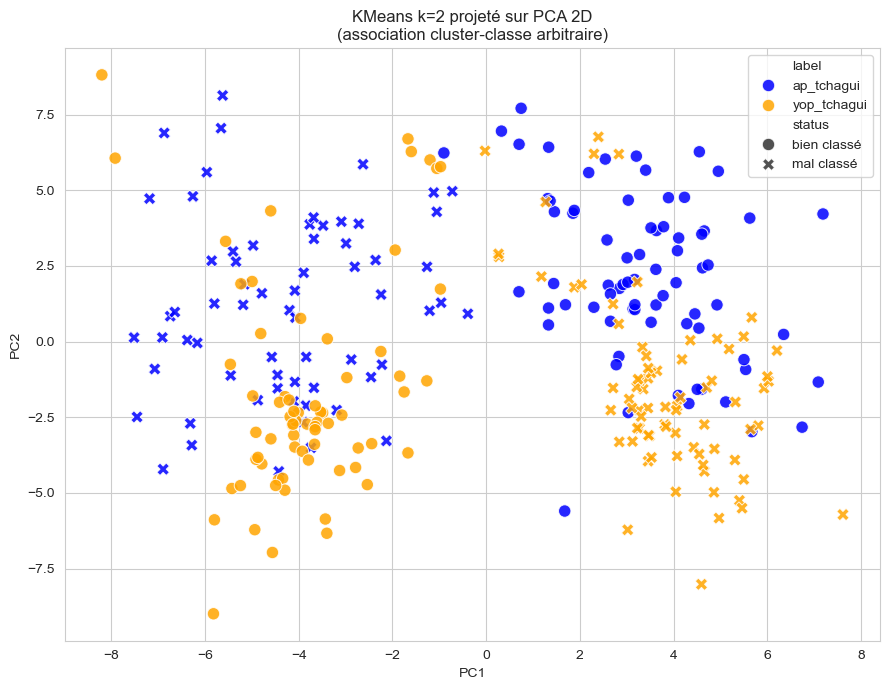

In [72]:
# Attribution arbitraire des clusters aux classes
cluster_to_label = {
    0: "yop_tchagui",
    1: "ap_tchagui"
}

pca_2d_df["cluster_kmeans_original"] = clusters

pca_2d_df["label_pred_cluster"] = (
    pca_2d_df["cluster_kmeans_original"]
    .astype(int)
    .map(cluster_to_label)
)

# Bien ou mal attribué selon cette convention
pca_2d_df["status"] = np.where(
    pca_2d_df["label"] == pca_2d_df["label_pred_cluster"],
    "bien classé",
    "mal classé"
)

palette = {
    "ap_tchagui": "blue",
    "yop_tchagui": "orange"
}

markers = {
    "bien classé": "o",
    "mal classé": "X"
}

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_2d_df,
    x="PC1",
    y="PC2",
    hue="label",
    style="status",
    palette=palette,
    markers=markers,
    s=80,
    alpha=0.85
)

plt.title(
    "KMeans k=2 projeté sur PCA 2D\n"
    "(association cluster-classe arbitraire)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()



Le KMeans ne parvient pas à faire émerger naturellement les deux techniques de taekwondo. Les deux clusters obtenus contiennent des proportions très similaires de ap_tchagui et yop_tchagui, ce qui suggère que la structure naturelle des données ne correspond pas directement aux classes étudiées.

## Random Forest sans PCA

Afin de détreminer la pertinence de l'utilisation de la PCA nous allons tester une classification supervisée par Random forest avec nos variables d'origines puis avec nos variables issues de la PCA.

Le premier entrainement sans PCA est la baseline supervisée : on entraîne le modèle directement sur les 84 variables originales.

In [73]:
# Séparation du jeu de train / test
y = y_raw
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (213, 84)
Test  : (71, 84)


In [74]:
# Création du modèle
rf_raw = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Entraînement du modèle
rf_raw.fit(
    X_train,
    y_train
)

# Prédictions sur le jeu de test
y_pred_raw = rf_raw.predict(
    X_test
)


In [75]:
# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred_raw
)

print(f"Accuracy : {accuracy:.3f}")

# Rapport de classification
print(
    classification_report(
        y_test,
        y_pred_raw
    )
)

# Matrice de confusion
cm = confusion_matrix(y_test,y_pred_raw)
print("Matrice de confusion :")
print(cm)


Accuracy : 0.944
              precision    recall  f1-score   support

  ap_tchagui       0.94      0.94      0.94        35
 yop_tchagui       0.94      0.94      0.94        36

    accuracy                           0.94        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.94      0.94      0.94        71

Matrice de confusion :
[[33  2]
 [ 2 34]]


## Random Forest avec PCA

On teste maintenant une Random Forest entraînée sur les composantes PCA.

In [76]:
# Préparation des données pour le modèle Random Forest avec PCA

# La PCA étant sensible à l'échelle des variables, les données doivent être standardisées 
# Le scaler est ajusté uniquement sur le jeu d'entraînement afin d'éviter toute fuite d'information provenant du jeu de test.
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(
    X_train
)

X_test_scaled = scaler_model.transform(
    X_test
)

In [77]:
# Réduction de dimension par PCA
# La PCA est également ajustée uniquement sur le jeu d'entraînement.

# On conserve automatiquement suffisamment de composantes pour expliquer 90 % de la variance totale des données.
pca_model = PCA(
    n_components=0.90,
    random_state=RANDOM_STATE
)

X_train_pca = pca_model.fit_transform(
    X_train_scaled
)

X_test_pca = pca_model.transform(
    X_test_scaled
)

print(
    "Nombre de composantes conservées :",
    pca_model.n_components_
)

print(
    "Shape train PCA :",
    X_train_pca.shape
)

print(
    "Shape test PCA :",
    X_test_pca.shape
)

Nombre de composantes conservées : 12
Shape train PCA : (213, 12)
Shape test PCA : (71, 12)


In [78]:
# Entraînement du Random Forest
rf_pca = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Entraînement du modèle sur les données PCA
rf_pca.fit(
    X_train_pca,
    y_train
)

# Prédictions sur le jeu de test
y_pred_pca = rf_pca.predict(
    X_test_pca
)


In [79]:
# Accuracy globale
accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print(f"Accuracy : {accuracy_pca:.3f}")

# Rapport détaillé
print(
    classification_report(
        y_test,
        y_pred_pca
    )
)

# Matrice de confusion
cm_pca = confusion_matrix(y_test,y_pred_pca)
print("Matrice de confusion :")
print(cm_pca)

Accuracy : 0.958
              precision    recall  f1-score   support

  ap_tchagui       0.92      1.00      0.96        35
 yop_tchagui       1.00      0.92      0.96        36

    accuracy                           0.96        71
   macro avg       0.96      0.96      0.96        71
weighted avg       0.96      0.96      0.96        71

Matrice de confusion :
[[35  0]
 [ 3 33]]


## Comparaison du Random Forest avec et sans ACP

Le modèle sans ACP obtient une accuracy de 94,4 %, avec seulement 4 erreurs de classification sur les 71 observations du jeu de test. Les performances sont équilibrées entre les deux classes.

Le modèle avec ACP obtient une accuracy légèrement supérieure de 95,8 %. La réduction de dimension n'a donc pas dégradé les performances du modèle, au contraire.

L'amélioration reste toutefois faible. Les résultats montrent donc que les variables d'origine contiennent déjà une information très pertinente pour la classification. L'ACP permet néanmoins de réduire le nombre de variables tout en conservant des performances comparables, voire légèrement meilleures.

Cependant, cette approche présente une limite : elle fait perdre l'interprétabilité métier des variables.